In [263]:
import pybamm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import keras
from sklearn.model_selection import train_test_split
from tqdm import trange

# import  settings
import plot_settings
plot_settings.apply()

In [257]:
path = "data/asheri_data.txt"
df = pd.read_csv(path, sep=r"\s+", engine="python")

# log j
df.iloc[:, 1] = -np.log10(df.iloc[:, 1] * -1)
# small j
df = df[df['j'] < 2]

display(df)

,Gc,j,c_old,soc_old,c_dot,soc_dot,d_dot
0,4.21,0.522879,0.500000,0.500000,7.409167,0.600128,0.000000
1,4.21,0.522879,0.507409,0.500600,3.954095,0.600128,0.000000
2,4.21,0.522879,0.511363,0.501200,2.974950,0.600129,0.000000
3,4.21,0.522879,0.514338,0.501800,2.501118,0.600128,0.000000
4,4.21,0.522879,0.516839,0.502401,2.208906,0.600128,0.000000
...,...,...,...,...,...,...,...
9628,13.92,1.698970,0.978937,0.979286,0.045015,0.040009,0.016262
9629,13.92,1.698970,0.984072,0.983787,0.046413,0.040009,0.016804
9630,13.92,1.698970,0.989381,0.988288,0.048159,0.040009,0.017262
9631,13.92,1.698970,0.994911,0.992788,0.050382,0.040009,0.017746


In [258]:
np.where(df['c_old'] == 0.5)
# 4465 - 4341 = 124
# index 4341 last cycle

(array([   0,  136,  279,  415,  565,  702,  836,  985, 1110, 1226, 1343,
        1467, 1601, 1743, 1879, 2029, 2166, 2299, 2452, 2633, 2748, 2852,
        2970, 3103, 3244, 3379, 3528, 3664, 3796, 3946, 4101, 4217, 4341]),)

In [260]:
X = df[['Gc', 'j', 'c_old', 'soc_old']].to_numpy()
y = df[['c_dot', 'soc_dot', 'd_dot']].to_numpy()
print(X[4343, :])
# print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X[:4340], y[:4340], test_size=0.25, random_state=42)
# print(X[4341, 2]) # start of the last cycle

# Scale the input features
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
scaler_X.fit(X_train)
X_train_scaled = scaler_X.transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = MinMaxScaler()
scaler_y.fit(y_train)
y_train_scaled = scaler_y.transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

print(X_train_scaled)
print(y_train_scaled)

[13.92        1.69897     0.50079598  0.50008802]
[[0.18125644 0.537393   0.23266936 0.21110621]
 [0.         0.74404198 0.38199104 0.37091001]
 [0.18125644 0.48808395 0.         0.        ]
 ...
 [1.         0.         0.92270523 0.81581042]
 [1.         0.537393   0.80554369 0.79263353]
 [0.         0.59431613 0.12748671 0.1089548 ]]
[[0.01399039 0.17857182 0.        ]
 [0.00570617 0.07142922 0.        ]
 [0.26289918 0.21428602 0.        ]
 ...
 [0.07979628 0.99999853 0.10691822]
 [0.01349981 0.17857182 0.0162501 ]
 [0.01127318 0.14285755 0.        ]]


In [ ]:
model = keras.models.Sequential([   
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(1024*3, activation='relu'),
    keras.layers.Dense(y_train.shape[1], activation='relu'),
])

model.compile(
  optimizer='adam', loss='mse', metrics=['accuracy'])

In [140]:
epochs = 500     ## Number of epoch to run
batch_size = 80  ## Number of samples per gradient update

#es = keras.callbacks.EarlyStopping('val_loss', patience=10, restore_best_weights = True)

# Train the model
history = model.fit(
  X_train_scaled, y_train_scaled,
  epochs=epochs,
  verbose = 1,
  batch_size=batch_size,
  #callbacks=[es]
  #validation_data=(X_valid, y_valid)
  )

Epoch 1/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8283 - loss: 0.0126   
Epoch 2/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7902 - loss: 0.0021 
Epoch 3/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8366 - loss: 0.0015 
Epoch 4/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8734 - loss: 0.0012
Epoch 5/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9088 - loss: 8.3886e-04
Epoch 6/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9290 - loss: 6.1041e-04 
Epoch 7/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9324 - loss: 5.3061e-04
Epoch 8/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9404 - loss: 4.5227e-04
Epoch 9/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9558 - loss: 4.2855e-04
Epoch 10/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9631 - loss: 3.7451e-04
Epoch 11/500
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9671 - loss: 3.3166e-04 
Epoch 12/500
41/41 ━━━━━━━━━

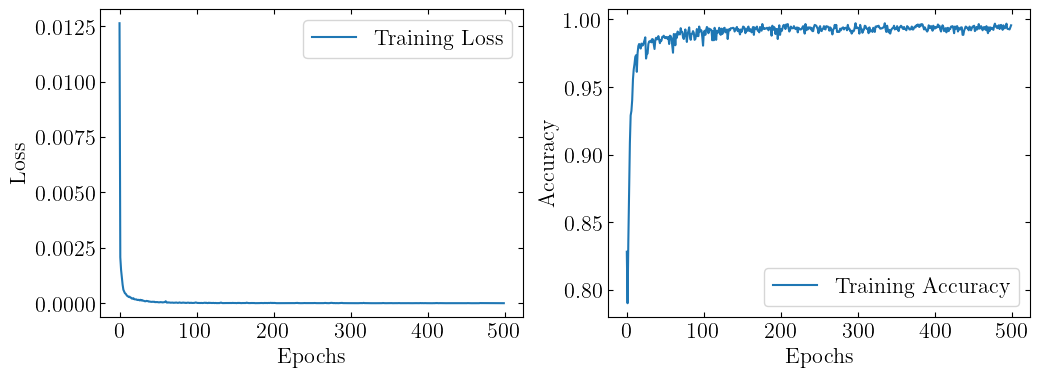

In [141]:
train_loss = history.history['loss']
accuracy = history.history['accuracy']
#valid_loss = history.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_loss, label='Training Loss')
ax2.plot(accuracy, label='Training Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax1.legend()
ax2.legend()

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step
[[0.10784747 0.10082403 0.        ]
 [0.03780222 0.0400081  0.08508541]
 [0.08167201 0.08039586 0.        ]
 ...
 [0.07881841 0.08017523 0.01286879]
 [0.14030534 0.13983515 0.01463819]
 [0.23498881 0.18105312 0.        ]]


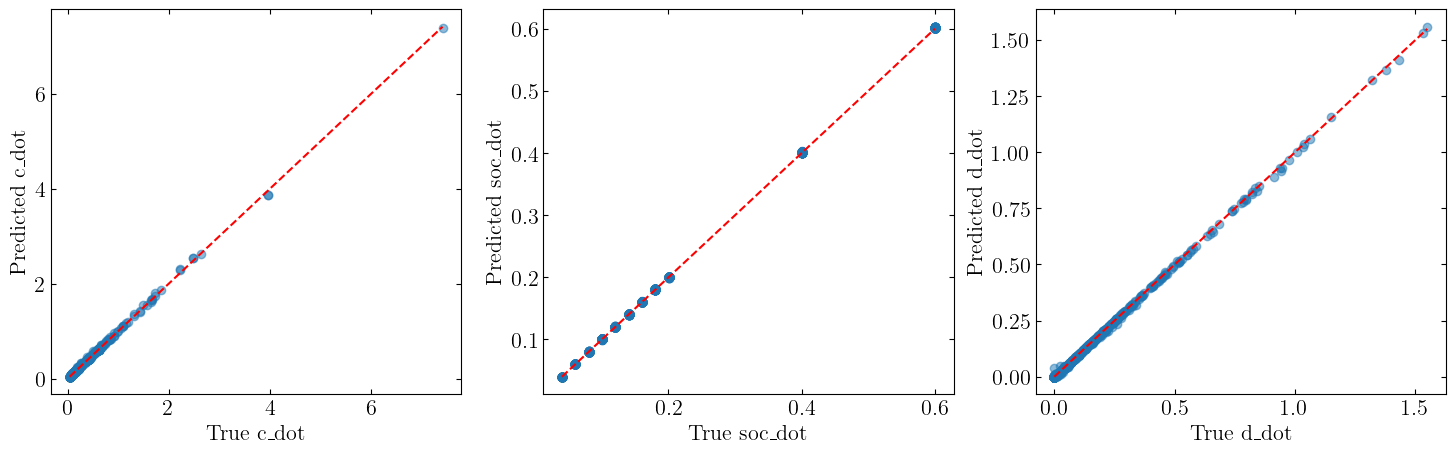

In [ ]:
pred_scaled = model.predict(X_test_scaled)

pred_denorm = scaler_y.inverse_transform(pred_scaled)

c_dot_pred = pred_denorm[:, 0]
soc_dot_pred = pred_denorm[:, 1]
d_dot_pred = pred_denorm[:, 2]

c_dot_true = y_test[:, 0]
soc_dot_true = y_test[:, 1]
d_dot_true = y_test[:, 2]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
ax1.scatter(c_dot_true, c_dot_pred, alpha=0.5)
ax1.plot([c_dot_true.min(), c_dot_true.max()], [c_dot_true.min(), c_dot_true.max()], 'r--', label='y=x')
ax1.set_xlabel('True c_dot')
ax1.set_ylabel('Predicted c_dot')

ax2.scatter(soc_dot_true, soc_dot_pred, alpha=0.5)
ax2.plot([soc_dot_true.min(), soc_dot_true.max()], [soc_dot_true.min(), soc_dot_true.max()], 'r--', label='y=x')
ax2.set_xlabel('True soc_dot')
ax2.set_ylabel('Predicted soc_dot')

ax3.scatter(d_dot_true, d_dot_pred, alpha=0.5)
ax3.plot([d_dot_true.min(), d_dot_true.max()], [d_dot_true.min(), d_dot_true.max()], 'r--', label='y=x')
ax3.set_xlabel('True d_dot')
ax3.set_ylabel('Predicted d_dot')


In [ ]:
pred_test_scaled = model.predict(scaler_X.transform(X[4341:4342, :]))
pred_test_denorm = scaler_y.inverse_transform(pred_test_scaled)

print('Input Gc, j, c_old, soc_old:')
print(X[4341:4342, :])
print('Predicted c_dot, soc_dot, d_dot:')
print(pred_test_denorm)
print('Actual c_dot, soc_dot, d_dot:')
print(y[4341:4342, :])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Input Gc, j, c_old, soc_old:
[[13.92     1.69897  0.5      0.5    ]]
Predicted c_dot, soc_dot, d_dot:
[[0.50681007 0.04647356 0.        ]]
Actual c_dot, soc_dot, d_dot:
[[0.49393109 0.04000854 0.        ]]


In [ ]:
# Setup for time evolution
Gc = X[4341, 0]
j = X[4341, 1]
print(Gc, j)

c = X[4341, 2]
soc = X[4341, 3]

dt = 1
num_steps = len(X[4341:, 2])
t_max = num_steps * dt    #len(X[4341:, 2])    #124
t = np.linspace(0, t_max, num_steps)
# print(X[4341:, 2])

13.92 1.6989700043360187


In [251]:
def derivative(c, soc, step):
    input_features = np.array([[Gc, j, c, soc]])
    input_scaled = scaler_X.transform(input_features)
    pred_scaled = model.predict(input_scaled, verbose=0)
    pred_denorm = scaler_y.inverse_transform(pred_scaled)
    c_dot = pred_denorm[0, 0]
    soc_dot = pred_denorm[0, 1]
    return c_dot, soc_dot

def Euler_step(c, soc, step):
    c_dot, soc_dot = derivative(c, soc, step)
    dt_actual = (X[4342+step, 2] - X[4341+step, 2]) / y[4341+step, 0]
    c_next = c + c_dot * dt_actual
    soc_next = soc + soc_dot * dt_actual
    return c_next, soc_next

def evolver(c, soc, num_steps):
    c_history = [c]
    soc_history = [soc]
    
    for step in range(0, num_steps-1):
        c, soc = Euler_step(c, soc, step)
        c_history.append(c)
        soc_history.append(soc)
    
    return np.array(c_history), np.array(soc_history)

c_history, soc_history = evolver(c, soc, num_steps)

In [ ]:
# c_history = [c]
# soc_history = [soc]

# # Time evolve
# for step in range(num_steps-1):
#     X_loop = np.array([[Gc, j, c, soc]])
#     X_scaled = scaler_X.transform(X_loop)

#     dots_scaled = model.predict(X_scaled, verbose=0)
#     dots = scaler_y.inverse_transform(dots_scaled)

#     c_dot = dots[0, 0]
#     soc_dot = dots[0, 1]
#     d_dot = dots[0, 2]

#     # time step discrepancy correction
#     dt_actual = (X[4342+step, 2] - X[4341+step, 2]) / y[4341+step, 0]   # (c_new - c_old) / c_dot

#     # Forward Euler integration     Asheri etal equations 34-35
#     c = c + c_dot * dt_actual
#     soc = soc + soc_dot * dt_actual
#     # d = d + d_dot * dt

#     c_history.append(c)
#     soc_history.append(soc)


In [ ]:
# # Time evolve
# for step in range(num_steps-1):

#     c_dot = y[4341+step, 0]
#     soc_dot = y[4341+step, 1]

#     dt_actual = (X[4342+step, 2] - X[4341+step, 2]) / y[4341+step, 0]

#     # Forward Euler integration     Asheri etal equations 34-35
#     c = c + c_dot * dt_actual
#     soc = soc + soc_dot * dt_actual

#     c_history.append(c)
#     soc_history.append(soc)

124


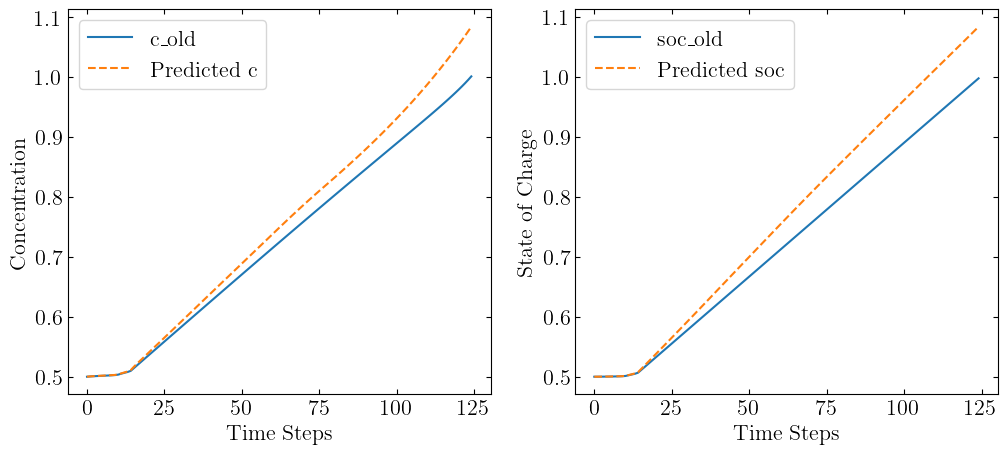

In [252]:
print(len(c_history))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(t, X[4341:, 2], label='c_old')
ax1.plot(t, c_history, '--', label='Predicted c')
ax1.set_xlabel('Time Steps')
ax1.set_ylabel('Concentration')
ax1.legend()

ax2.plot(t, X[4341:, 3], label='soc_old')
ax2.plot(t, soc_history, '--', label='Predicted soc')
ax2.set_xlabel('Time Steps')
ax2.set_ylabel('State of Charge')
ax2.legend()

In [255]:
path = "data/df_c_dot.csv"
df = pd.read_csv(path, sep=",", engine="python")

# # log j
# df.iloc[:, 1] = -np.log10(df.iloc[:, 1] * -1)
# # small j
# df = df[df['j'] < 2]

display(df)

,Unnamed: 0,co,cn,c-dot,dt
0,0,29267.433751,29272.490645,2.650560,2.003251
1,1,29272.490645,29277.805731,2.785891,2.003251
2,2,29277.805731,29283.333555,2.897397,2.003251
3,3,29283.333555,29289.044637,2.993452,2.003251
4,4,29289.044637,29294.913005,3.075893,2.003251
...,...,...,...,...,...
1213,1213,45874.507209,45888.452383,7.309333,2.003251
1214,1214,45888.452383,45902.397557,7.309333,2.003251
1215,1215,45902.397557,45916.342731,7.309333,2.003251
1216,1216,45916.342731,45930.287906,7.309333,2.003251


In [ ]:



X_ = df[['Gc', 'j', 'c_old', 'soc_old']].to_numpy()
y_ = df[['c_dot', 'soc_dot', 'd_dot']].to_numpy()
print(X[4343, :])
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X[:4340], y[:4340], test_size=0.25, random_state=42)

# Scale the input features
from sklearn.preprocessing import MinMaxScaler
scaler_X = MinMaxScaler()
scaler_X.fit(X_train)
X_train_scaled = scaler_X.transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

scaler_y = MinMaxScaler()
scaler_y.fit(y_train)
y_train_scaled = scaler_y.transform(y_train)
y_test_scaled = scaler_y.transform(y_test)